# Terminated Awards

In [1]:
import pandas as pd

In [2]:
# read in data

terminated_awards = pd.read_csv("/Users/ryanseely/Documents/GitHub/reu_nsf/NSF-Terminated-Awards.csv", encoding='latin1')


In [9]:
terminated_awards.head(40)

,Award ID,Directorate,Recipient,Title,Obligated,Unnamed: 5,Date of export: 6/5/2025
0,1231319,MPS,Harvard University ...,Center for Integrated Quantum Materials,44434393.0,NaN,NaN
1,1432910,EDU,Regents of the University of Idaho ...,Collaborative Research: The Pacific Northwest ...,1257442.0,NaN,NaN
2,1661201,EDU,Purdue University ...,Collaborative Research: Identity Development E...,555089.0,NaN,NaN
3,1712692,EDU,Auburn University ...,The Greater Alabama Black Belt Region (GABBR) ...,4999995.0,NaN,NaN
4,1723165,EDU,Texas A&M University Corpus Christi ...,Collaborative Research: The Texas A&M System A...,614061.0,NaN,NaN
5,1723209,EDU,CUNY City College ...,Collaborative Research: The Hispanic AGEP Alli...,2315184.0,NaN,NaN
6,1723245,EDU,University of Texas at El Paso ...,Collaborative Research: The Hispanic AGEP Alli...,1262377.0,NaN,NaN
7,1736019,EDU,University of Puerto Rico Medical Sciences Cam...,Puerto Rico Center for Environmental Neuroscie...,5100000.0,NaN,NaN
8,1743117,MPS,University of California-Santa Cruz ...,Advancing Inclusive Leaders in Astronomy,1420207.0,NaN,NaN
9,1761287,EDU,Xavier University of Louisiana ...,Xavier ADVANCE Adaptation - Supporting Transfo...,1013337.0,NaN,NaN


In [4]:
print(f"There were {len(terminated_awards)} awards terminated when Trump took office")

There were 1667 awards terminated when Trump took office


In [5]:
# Make the "Obligated" column numeric
terminated_awards['Obligated'] = terminated_awards['Obligated'].replace('[\$,]', '', regex=True).astype(float)

In [6]:
total_obligated = terminated_awards['Obligated'].sum()
print(f"Total Obligated: ${total_obligated:,.2f}")

Total Obligated: $1,345,131,506.00


In [7]:
mean_obligated = terminated_awards['Obligated'].mean()
print(f"Mean Obligated: ${mean_obligated:,.2f}")

Mean Obligated: $806,917.52


In [8]:
# How many canclled REUs
reu_count = terminated_awards['Title'].str.contains("REU", case=False, na=False).sum()
print(f"Rows with 'REU' in Title: {reu_count}")

Rows with 'REU' in Title: 22


In [10]:
# How many cancelled career awards?
career_count = terminated_awards['Title'].str.contains("CAREER", case=False, na=False).sum()
print(f"Rows with 'CAREER' in Title: {career_count}")

Rows with 'CAREER' in Title: 191


In [11]:
# How many cancelled fellowships?
fellow_count = terminated_awards['Title'].str.contains("Fellowship", case=False, na=False).sum()
print(f"Rows with 'Fellowship' in Title: {fellow_count}")

Rows with 'Fellowship' in Title: 18


In [12]:
# How many cancelled conferences?
conference_count = terminated_awards['Title'].str.contains("Conference", case=False, na=False).sum()
print(f"Rows with 'Conference' in Title: {conference_count}")

Rows with 'Conference' in Title: 65


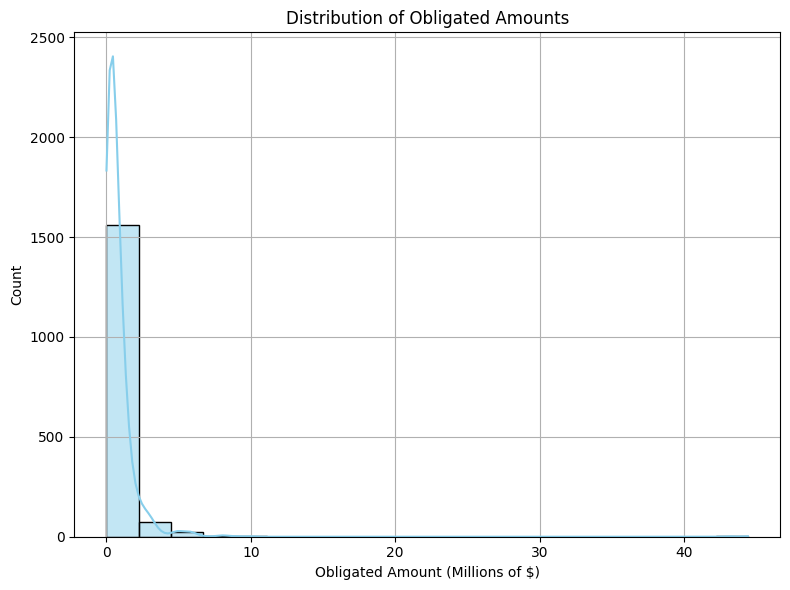

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a new column in millions
terminated_awards['Obligated_Millions'] = terminated_awards['Obligated'] / 1_000_000

plt.figure(figsize=(8, 6))
sns.histplot(terminated_awards['Obligated_Millions'], bins=20, kde=True, color='skyblue')

plt.title('Distribution of Obligated Amounts')
plt.xlabel('Obligated Amount (Millions of $)')
plt.ylabel('Count')

# Optionally: show gridlines and formatted ticks
plt.grid(True)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()
